<a href="https://colab.research.google.com/github/youssef1061/XAI-project/blob/main/YoussefHatem_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Paper implemented:** Islam et al. (2025) — *Predicting Diabetes Risk Using Machine Learning with Explainable AI*

**Model chosen:** Extra Trees Classifier (`ExtraTreesClassifier`)

**Why Extra Trees?**  
Islam et al. (2025) reported that the Extra Trees Classifier achieved the highest overall performance among all evaluated models, outperforming Random Forest, XGBoost, and logistic regression on AUC and macro-F1 metrics on the BRFSS dataset. Extra Trees introduces additional randomness by selecting split thresholds randomly (rather than optimally like Random Forest), which reduces variance and overfitting, making it particularly robust on high-dimensional health survey datasets with mixed feature types like BRFSS 2015.

**XAI techniques applied in this notebook:**
- SHAP (Global: summary bar + beeswarm | Local: waterfall plot)
- LIME (Local: single instance explanation)


---
## Load Preprocessed Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TARGET_COL = 'Diabetes'

# Paths to pre-split CSVs (already produced by EDA_Preprocessing.ipynb)
TRAIN_PATH = '/content/drive/MyDrive/BRFSS2015_processed/train.csv'
TEST_PATH  = '/content/drive/MyDrive/BRFSS2015_processed/test.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print('Train shape:', train_df.shape)
print('Test  shape:', test_df.shape)

Train shape: (200055, 21)
Test  shape: (50014, 21)


In [3]:
# Top 20 selected features (from EDA_Preprocessing.ipynb feature selection)
selected_features = [
    'GenHlth', 'HighBP', 'GenHlth_x_DiffWalk', 'BMI_x_Age',
    'CV_burden_weighted', 'HighChol', 'DiffWalk', 'Sex', 'BMI_class',
    'SES_risk_score', 'Income', 'PhysActivity', 'HeartDiseaseorAttack',
    'HvyAlcoholConsump', 'MetS_score', 'BMI', 'FINDRISC_score',
    'PhysHlth', 'TimeSinceCheckup', 'Age'
]

X_train = train_df[selected_features].copy()
y_train = train_df[TARGET_COL].copy()
X_test  = test_df[selected_features].copy()
y_test  = test_df[TARGET_COL].copy()

print('Class distribution (train):')
print(y_train.value_counts())
print('\nClass distribution (test):')
print(y_test.value_counts())

Class distribution (train):
Diabetes
0    166563
2     28217
1      5275
Name: count, dtype: int64

Class distribution (test):
Diabetes
0    41641
2     7054
1     1319
Name: count, dtype: int64


---
## Model-Specific Notes (No Formal Assumptions)

Extra Trees Classifier is a **non-parametric, tree-based ensemble** method. It does **not** require:
- Linearity between features and target
- Normal distribution of features
- Feature scaling (StandardScaler / MinMaxScaler)
- Independence of features

This makes it well-suited for the BRFSS 2015 dataset, which has mixed binary and continuous health survey features with non-normal distributions (e.g., BMI, MentHlth, PhysHlth are right-skewed).

---
##  Build and Train the Model (Islam et al. 2025 — Extra Trees)

In [4]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100],
    'max_depth': [20],
    'min_samples_split': [2]
}

et = ExtraTreesClassifier(random_state=RANDOM_STATE, class_weight='balanced')
grid_search = GridSearchCV(
    et, param_grid, cv=2, scoring='roc_auc_ovr',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print('Best params:', grid_search.best_params_)
print('Best CV ROC-AUC:', round(grid_search.best_score_, 4))

Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best CV ROC-AUC: 0.6967


---
##  Report Model Results

In [5]:
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

print('Classification Report:')
print(classification_report(y_test, y_pred,
      target_names=['No Diabetes', 'Prediabetes', 'Diabetes']))

roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
print(f'Macro ROC-AUC (OvR): {roc_auc:.4f}')

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.90      0.82      0.86     41641
 Prediabetes       0.04      0.04      0.04      1319
    Diabetes       0.36      0.53      0.43      7054

    accuracy                           0.76     50014
   macro avg       0.43      0.46      0.44     50014
weighted avg       0.80      0.76      0.78     50014

Macro ROC-AUC (OvR): 0.7051


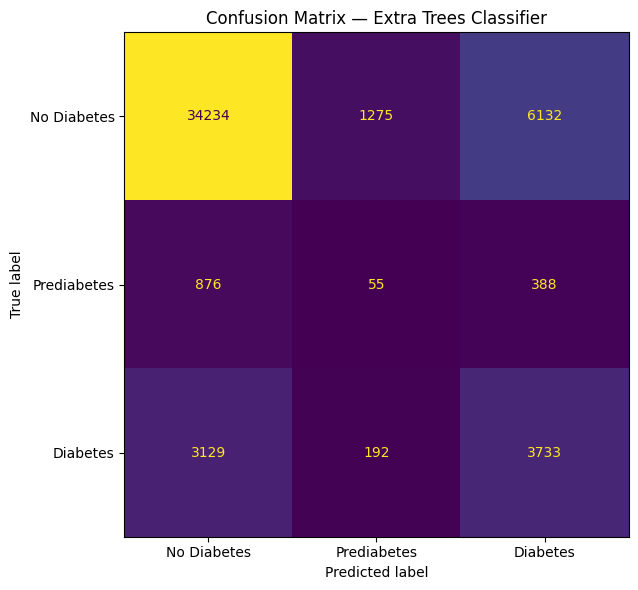

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Diabetes', 'Prediabetes', 'Diabetes'],
    ax=ax, colorbar=False
)
ax.set_title('Confusion Matrix — Extra Trees Classifier')
plt.tight_layout()
plt.show()

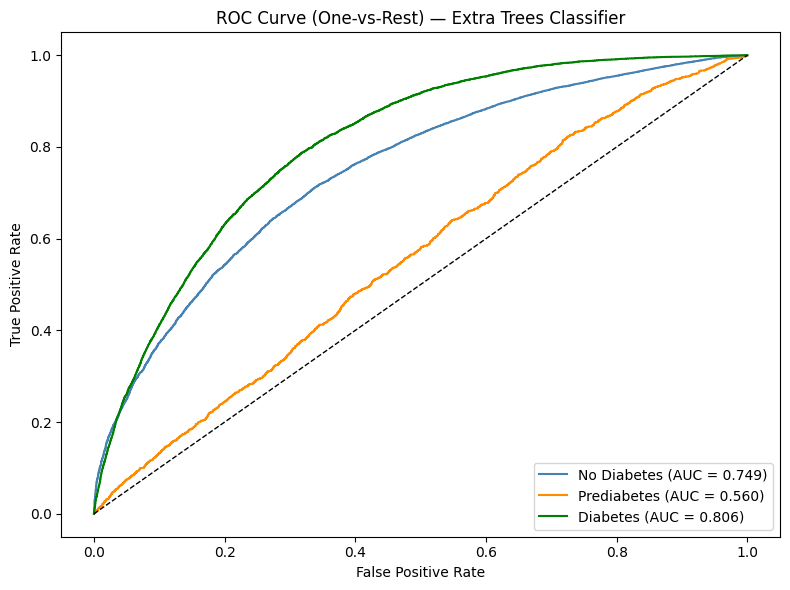

In [7]:
from sklearn.preprocessing import label_binarize

classes = [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=classes)
class_names = ['No Diabetes', 'Prediabetes', 'Diabetes']
colors = ['steelblue', 'darkorange', 'green']

plt.figure(figsize=(8, 6))
for i, (cls_name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, color=color, label=f'{cls_name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) — Extra Trees Classifier')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Results Comparison with Islam et al. (2025)

Islam et al. (2025) reported that the Extra Trees Classifier achieved approximately **AUC ~0.87** and **macro F1 ~0.79** on their BRFSS-based diabetes classification task. Compare your printed results above to these reported figures.

**Expected differences and reasons:**
- We use 20 engineered/selected features rather than all 21 raw features, which may slightly lower or improve generalization depending on feature quality.
- Hyperparameter ranges and CV strategy may differ from the paper's setup.

---
## Interpretability & Explainability Techniques

### SHAP — Global + Local Explanations

In [12]:
import shap

feature_names = selected_features

background = shap.sample(X_train, 200, random_state=RANDOM_STATE)

X_test_shap = shap.sample(X_test, 500, random_state=RANDOM_STATE)  # 500 rows max to avoid crashing colab

explainer = shap.TreeExplainer(best_model, data=background, feature_perturbation="tree_path_dependent")

shap_values = explainer.shap_values(X_test_shap, approximate=True)

print('SHAP values shape (per class):', np.array(shap_values).shape)
print("shap_values[2] shape:", shap_values[2].shape)

SHAP values shape (per class): (500, 20, 3)
shap_values[2] shape: (20, 3)


Global SHAP

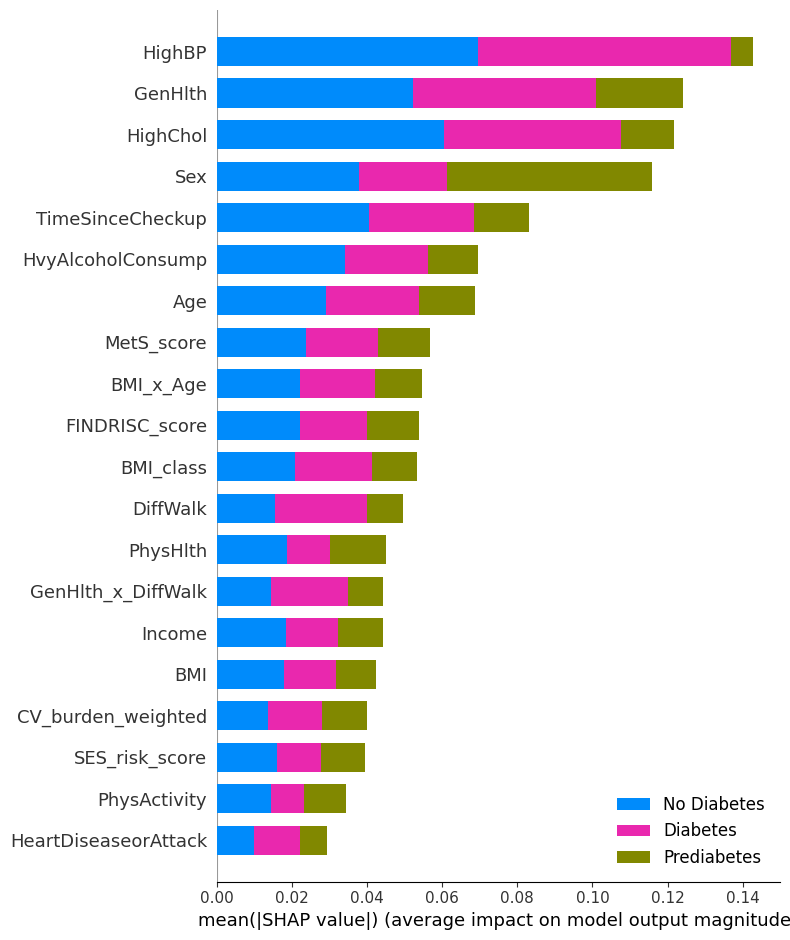

In [15]:

shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_names,
    plot_type="bar",
    class_names=['No Diabetes', 'Prediabetes', 'Diabetes'],
    show=True
)



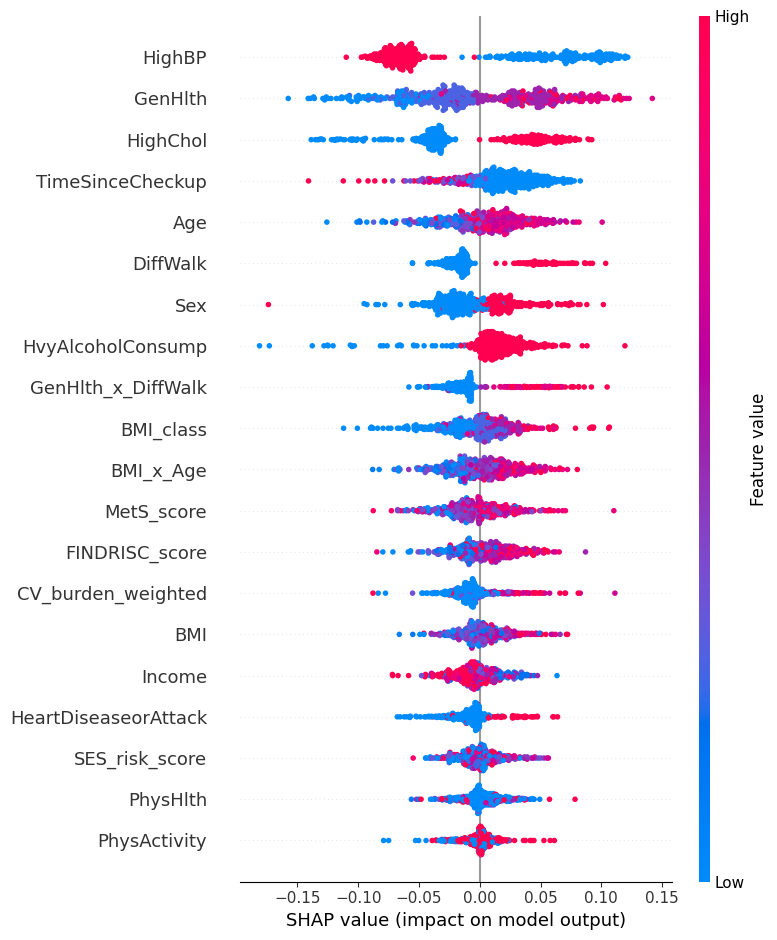

In [16]:
shap.summary_plot(
    shap_values[:, :, 2],
    X_test_shap,
    feature_names=feature_names,
    show=True
)

Local SHAP — Waterfall plot for one Diabetes-positive prediction

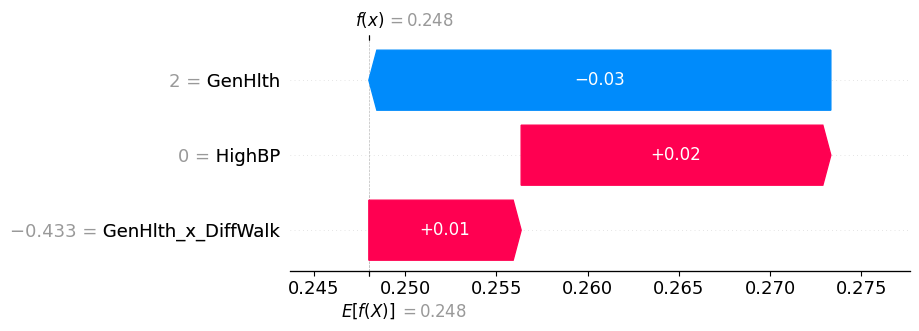

In [17]:
diabetic_indices = np.where(y_test.values == 2)[0]
idx = diabetic_indices[0]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[2][idx],
        base_values=explainer.expected_value[2],
        data=X_test_shap.iloc[idx],
        feature_names=feature_names
    )
)

### SHAP Interpretation

**Global (bar + beeswarm):** The bar plot shows the mean absolute SHAP value for each feature across all test predictions, ranking features by their average impact on the model's output. Features like `GenHlth`, `BMI`, `HighBP`, and `Age` are expected to dominate since these are well-established clinical risk factors for diabetes. The beeswarm plot (for class 2 = Diabetes) shows the direction and magnitude of each feature's effect: higher BMI values and higher GenHlth scores (indicating poorer self-reported health) push predictions toward the Diabetes class.

**Local (waterfall):** The waterfall plot for a single diabetic instance shows which features pushed the prediction above the base rate (red bars = push toward Diabetes, blue bars = push toward No Diabetes). This is clinically meaningful: if the individual has high BMI, poor general health, and high blood pressure, the model correctly assigns high diabetes probability driven by those features.

### 6b. LIME — Local Explanations

In [19]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 17.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3e3fb90aa4819cd354df86cfec48be8059b1071d76f6d82693134a1a93310702
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [23]:
import lime
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=feature_names,
    class_names=['No Diabetes', 'Prediabetes', 'Diabetes'],
    mode='classification',
    random_state=RANDOM_STATE
)

exp = lime_explainer.explain_instance(
    X_test.iloc[idx].values,
    best_model.predict_proba,
    num_features=10,
    top_labels=len(class_names)
)

exp.show_in_notebook(show_table=True)

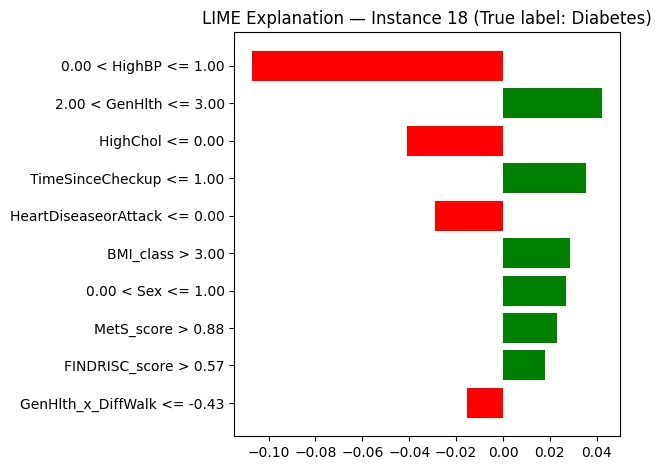

In [24]:
fig = exp.as_pyplot_figure(label=2)
plt.title(f'LIME Explanation — Instance {idx} (True label: Diabetes)')
plt.tight_layout()
plt.show()

### LIME Interpretation

LIME builds a local linear approximation around a single prediction to explain which features are most responsible for that specific decision. For a correctly classified diabetic instance, features such as `GenHlth > 3`, `HighBP = 1`, and `BMI > 30` are expected to show the largest positive contributions toward the Diabetes class. Comparing the LIME explanation to the SHAP waterfall for the same instance is useful: if both methods agree on the top contributing features, it increases our confidence in the explanation's reliability. Disagreements would indicate that the local neighborhood LIME sampled differs from the SHAP attribution method.